# Using spOT-NMF as a factorization backend in mosaicMPI

[mosaicMPI](https://github.com/MorrissyLab/mosaicMPI) is a framework for
**consensus matrix factorization, rank (k) selection, and multi-dataset
integration** of omics data. Out of the box it factorizes with consensus NMF
(cNMF, scikit-learn NMF under the hood).

`spOT-NMF` implements an **optimal-transport NMF (OT-NMF)** that accounts for
gene–gene relationships through a ground cost. This tutorial shows how to plug
spOT-NMF in as mosaicMPI's factorization engine, so that a single spOT-NMF
solve becomes one replicate inside mosaicMPI's consensus pipeline. You then get
everything mosaicMPI provides — replicate consensus, a stability/error rank
selection curve, program-usage heatmaps, and cross-dataset integration — driven
by OT-NMF instead of vanilla NMF.

The only change versus a standard mosaicMPI run is a single argument:
`initialize_cnmf(..., algorithm="spotnmf")`.

**Requirements:** `pip install spot-nmf mosaicmpi` (spOT-NMF needs
[PyTorch](https://pytorch.org); the usage heatmap in step 7 needs
`PyComplexHeatmap`). Importing this notebook's cells registers the `spotnmf`
backend with mosaicMPI automatically.

> This is a downsized demo (a subsample of a public Visium slide, a few ranks,
> few replicates) so it runs in under a minute on CPU. For real analyses use the
> full dataset, the default rank range, and `n_iter` of 100–200.

## 0. Setup

In [1]:
import numpy as np
import scanpy as sc
import mosaicmpi

# Importing the adapter registers spOT-NMF as the "spotnmf" backend.
# (mosaicMPI also autoloads it on demand when algorithm="spotnmf".)
import spotnmf.mosaic  # noqa: F401

mosaicmpi.start_logging()
print("mosaicMPI", mosaicmpi.__version__)
print("registered factorization backends:", mosaicmpi.factorization.available_factorizers())

mosaicMPI 2.8.8
registered factorization backends: ['cnmf', 'spotnmf']


## 1. Load a spatial dataset from scanpy

We use the public 10x Genomics **Visium Human Lymph Node** slide, downloaded
directly through scanpy. It contains raw UMI counts and spot coordinates.

In [2]:
adata = sc.datasets.visium_sge(sample_id="V1_Human_Lymph_Node")
adata.var_names_make_unique()
print("full slide:", adata.shape, "| spatial coords:", "spatial" in adata.obsm)

  0%|          | 0.00/7.86M [00:00<?, ?B/s]

  6%|▌         | 456k/7.86M [00:00<00:01, 4.64MB/s]

 12%|█▏        | 952k/7.86M [00:00<00:01, 4.32MB/s]

 26%|██▌       | 2.02M/7.86M [00:00<00:00, 7.28MB/s]

 34%|███▍      | 2.66M/7.86M [00:00<00:00, 6.58MB/s]

...

 94%|█████████▍| 27.6M/29.3M [00:04<00:00, 6.87MB/s]

 95%|█████████▍| 27.7M/29.3M [00:04<00:00, 2.68MB/s]

100%|██████████| 29.3M/29.3M [00:04<00:00, 6.60MB/s]

Z:\postdoc\projects\spOT-NMF\.venv\Lib\site-packages\anndata\_core\anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
Z:\postdoc\projects\spOT-NMF\.venv\Lib\site-packages\anndata\_core\anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


full slide: (4035, 36601) | spatial coords: True


## 2. Subsample for a fast demo

OT-NMF is heavier than plain NMF, so for this tutorial we keep 150 spots and
the 300 most-variable genes. Skip this cell to run on the full slide.

In [3]:
sc.pp.filter_genes(adata, min_cells=30)
rng = np.random.default_rng(0)
adata = adata[rng.choice(adata.n_obs, size=150, replace=False)].copy()

X = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
top = np.argsort(X.var(axis=0))[::-1][:300]
adata = adata[:, np.sort(top)].copy()
print("subsampled:", adata.shape)

subsampled: (150, 300)


## 3. Build a mosaicMPI `Dataset` and select highly variable features

mosaicMPI wraps the AnnData in a `Dataset` (treating `X` as raw counts here) and
models gene overdispersion to pick the features used for factorization.

In [4]:
ds = mosaicmpi.Dataset(adata)
ds.select_hvf(score_type="odscore", top_n=200, n_splines=5, spline_order=3)
print("HVFs selected:", int(ds.adata.var["selected"].sum()))

HVFs selected: 200


## 4. Factorize with the spOT-NMF backend

`initialize_cnmf` writes the factorization inputs and records which backend to
use. Passing `algorithm="spotnmf"` swaps the per-replicate factorizer from
scikit-learn NMF to spOT-NMF's OT-NMF. `factorizer_params` forwards keyword
arguments to `spotnmf.models.run_spotnmf` (e.g. the entropic regularizers `h`,
`w`, `eps`, the learning rate `lr`, and iteration caps). **As of the latest
release these OT hyperparameters ship as tuned defaults** — the `adam`
optimizer with `h=1e-2`, `w=1e-2`, `eps=2e-2`, `lr=1e-2`, a cosine ground
cost and row normalization — so you normally only override the iteration
caps or the device.

Everything downstream — consensus, rank selection, the on-disk output format —
is identical to a normal cNMF run, so no other code needs to change.

In [5]:
cnmf_results_dir = "spotnmf_mosaic_results"
run_name = "lymphnode_spotnmf"
kvals = [2, 3, 4, 5, 6, 7, 8]   # ranks to test (use a wider range for real data)
n_iter = 10                      # replicates per rank for the consensus

run = ds.initialize_cnmf(
    cnmf_output_dir=cnmf_results_dir,
    cnmf_name=run_name,
    kvals=kvals,
    n_iter=n_iter,
    algorithm="spotnmf",
    # spOT-NMF now applies its tuned OT defaults automatically (adam optimizer,
    # h=1e-2, w=1e-2, eps=2e-2, lr=1e-2, cost="cosine", normalize_rows=True);
    # here we only cap iterations and pin the device to keep the demo fast.
    factorizer_params={"max_iter": 8, "max_iter_inner": 40, "device": "cpu"},
)
print("backend:", run.algorithm, "| params:", run.factorizer_params)

backend: spotnmf | params: {'max_iter': 8, 'max_iter_inner': 40, 'device': 'cpu'}


In [6]:
import os, contextlib

# Run OT-NMF for every (rank, replicate). spOT-NMF prints per-solve progress;
# we silence it here to keep the notebook tidy (mosaicMPI's own logging remains).
with open(os.devnull, "w") as _null, contextlib.redirect_stdout(_null), contextlib.redirect_stderr(_null):
    run.factorize(verbose=False)

# Build the consensus solution across replicates for each rank.
run.postprocess()

# Merge the consensus programs and usages back into the Dataset.
ds.add_cnmf_results(cnmf_output_dir=cnmf_results_dir, cnmf_name=run_name)
print("results loaded into Dataset:", ds.has_cnmf_results)

results loaded into Dataset: True


## 5. Rank (k) selection

mosaicMPI computes a **stability** (silhouette of the replicate clustering) and a
**reconstruction error** for each rank — the basis for choosing k. This works
unchanged with the OT-NMF backend.

   stability  prediction_error
k                             
2   0.046116     123440.610888
3   0.088083     115625.794120
4   0.077278      97111.484892
5   0.144858      38677.918932
6   0.133516      61428.995001
7   0.129586      22545.073875
8   0.194355      17635.235434


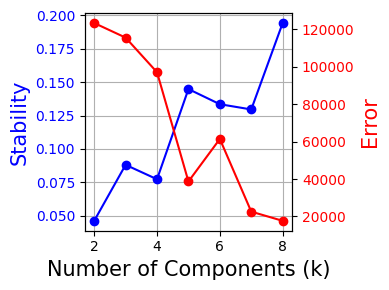

In [7]:
print(ds.adata.uns["kvals"])
fig = mosaicmpi.plot_stability_error(ds, figsize=[4, 3])

## 6. Program usages and gene programs

In [8]:
usages = ds.get_usages()
print("usage matrix (spots x programs):", usages.shape)
usages.head()

usage matrix (spots x programs): (150, 35)


2                 3                          4  \
                          1        2        1        2        3        1   
TAATGTCGGTTCATGG-1 0.733773 0.227764 0.699698 0.200343 0.063350 0.558178   
TCCTAAATTGGGAAGC-1 0.785971 0.237390 0.739634 0.211446 0.074857 0.552202   
TCCCTCCGAAATCGTT-1 0.795699 0.235125 0.796488 0.184333 0.037326 0.534241   
AAACTCGGTTCGCAAT-1 0.720488 0.322111 0.668460 0.225070 0.123524 0.559552   
CGCGGTAAGTCTAGCT-1 0.751716 0.365299 0.779088 0.252631 0.059944 0.393213   

                                                     5  ...        7           \
                          2        3        4        1  ...        6        7   
TAATGTCGGTTCATGG-1 0.149806 0.220751 0.019567 0.693012  ... 0.015281 0.018055   
TCCTAAATTGGGAAGC-1 0.161010 0.256111 0.026452 0.726847  ... 0.002802 0.016623   
TCCCTCCGAAATCGTT-1 0.108671 0.312431 0.007520 0.691640  ... 0.076544 0.027929   
AAACTCGGTTCGCAAT-1 0.267758 0.204952 0.017636 0.748697  ... 0.000226 0.032374   
CGCGGTAAGTCTAGCT-1 0.252729 0.363309 0.008278 0.588547  ... 0.098333 0.067282   

                          8                                               \
                          1        2        3        4        5        6   
TAATGTCGGTTCATGG-1 0.799017 0.028057 0.006793 0.051280 0.043389 0.005939   
TCCTAAATTGGGAAGC-1 0.900578 0.029333 0.002925 0.053730 0.007314 0.009665   
TCCCTCCGAAATCGTT-1 0.722494 0.022422 0.000000 0.124211 0.046621 0.022308   
AAACTCGGTTCGCAAT-1 0.871561 0.022825 0.085477 0.000601 0.015526 0.035800   
CGCGGTAAGTCTAGCT-1 0.710102 0.015919 0.104857 0.135678 0.001271 0.007765   

                                      
                          7        8  
TAATGTCGGTTCATGG-1 0.006145 0.000000  
TCCTAAATTGGGAAGC-1 0.000006 0.000000  
TCCCTCCGAAATCGTT-1 0.014558 0.000000  
AAACTCGGTTCGCAAT-1 0.001226 0.003969  
CGCGGTAAGTCTAGCT-1 0.043063 0.002320  

[5 rows x 35 columns]

In [9]:
programs = ds.get_programs(k=6, type="cnmf_gep_score")
print("k=6 gene programs (genes x programs):", programs.shape)
programs.iloc[:5]

k=6 gene programs (genes x programs): (300, 6)


program,1,2,3,4,5,6
RPL22,-0.003885,0.006666,-0.021877,0.031593,0.018557,-0.015700
ENO1,-0.001440,-0.006775,-0.015816,0.039617,-0.010873,0.089073
C1QA,-0.005734,-0.006720,0.003863,0.033942,0.007416,0.089407
RPL11,-0.004340,0.004199,-0.023560,0.059175,-0.000841,-0.012161
SH3BGRL3,-0.002021,-0.002540,-0.014601,0.029024,0.003262,0.039990


## 7. Usage heatmap

Any mosaicMPI visualization now reflects the OT-NMF programs.

Plotting HeatmapAnnotations


Z:\postdoc\projects\spOT-NMF\.venv\Lib\site-packages\PyComplexHeatmap\utils.py:569: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  cax.set_ylim([vmin, vmax])


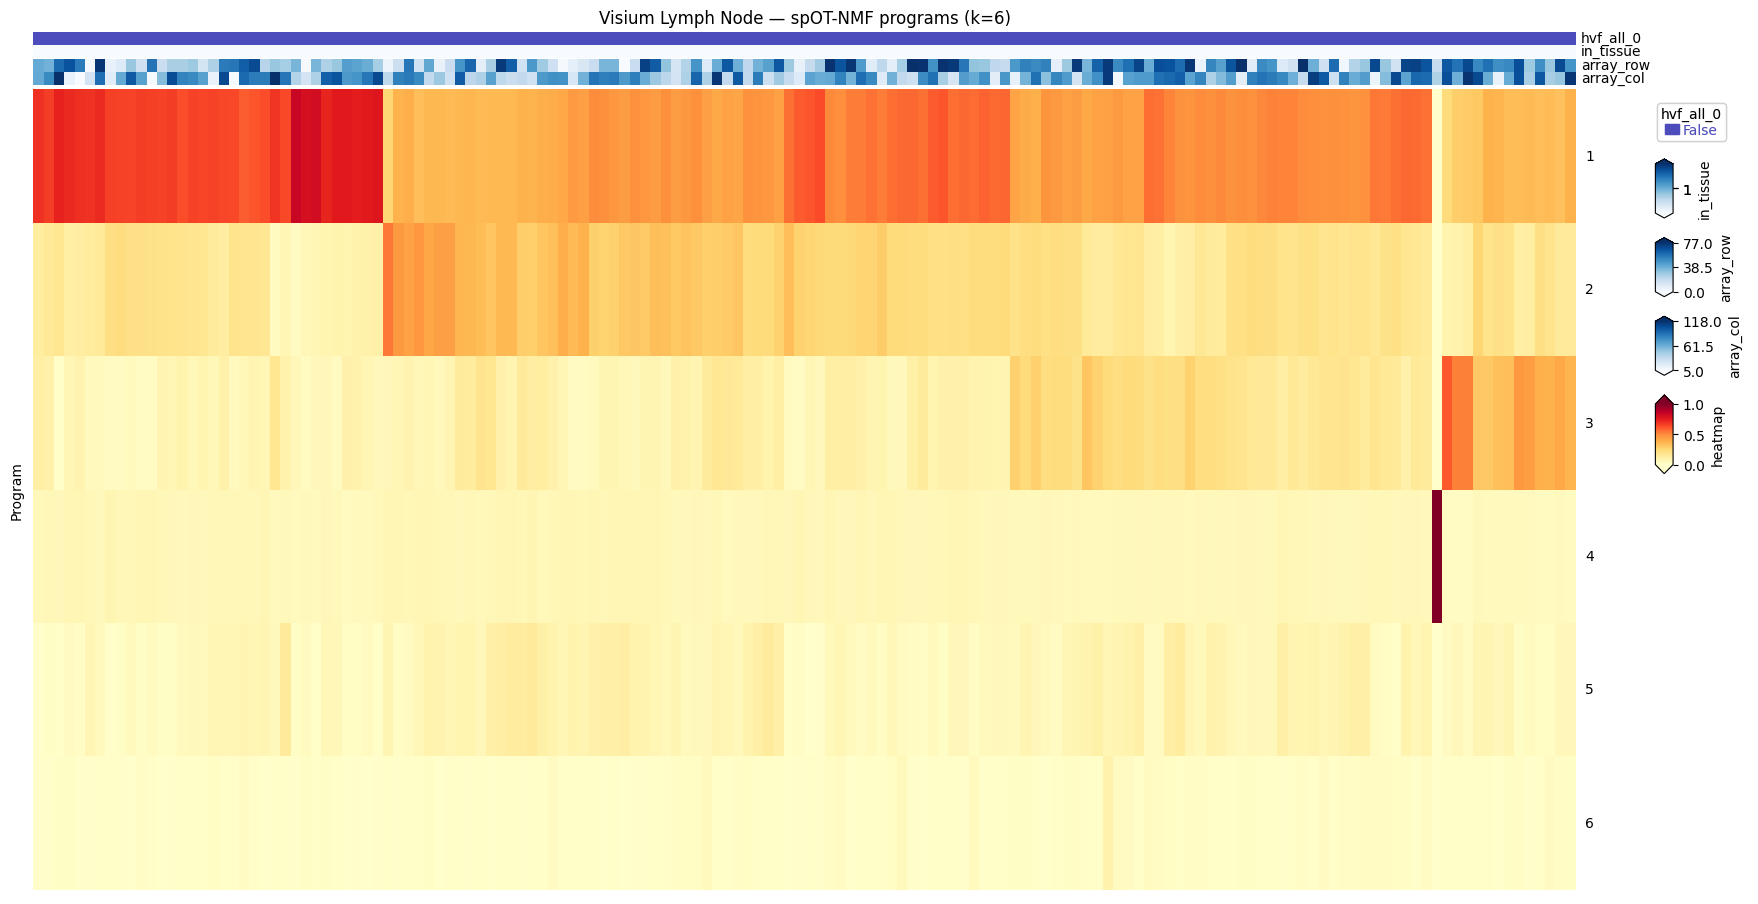

In [10]:
colors = mosaicmpi.Colors.from_dataset(ds, pastel_factor=0.4)
fig = mosaicmpi.plot_usage_heatmap(
    ds, k=6, colors=colors,
    title="Visium Lymph Node — spOT-NMF programs (k=6)")

## 8. Program network and community detection

This is what mosaicMPI is really built for: it correlates every program against
every other program (here across ranks 2–8 of one dataset; with several datasets
it does so across all of them), builds a graph of the most similar programs, and
detects **communities** of recurring programs. This works identically on the
OT-NMF programs produced above — nothing about the network step is cNMF-specific.

We use `corr_method="spearman"` so the correlation step needs no multiprocessing
(robust on any platform, including Windows notebooks). On Linux, or from a script
guarded by `if __name__ == "__main__":`, the default `"pearson"` uses all CPUs.

In [11]:
integration = mosaicmpi.Integration(
    datasets={"LymphNode": ds},
    k_subset=kvals,
    corr_method="spearman",       # avoids multiprocessing; default "pearson" is multi-CPU
    negative_corr_quantile=0.80,  # lower => keep more edges (this is a small demo network)
)
print("programs correlated:", integration.get_programs().shape[1],
      "| ranks:", integration.selected_k)

programs correlated: 35 | ranks: {'LymphNode': [2, 3, 4, 5, 6, 7, 8]}


In [12]:
network = mosaicmpi.Network(integration)
network.community_search(algorithm="greedy_modularity", resolution=1.0)
network.compute_layout(algorithm="spring", seed=7)  # deterministic, readable layout
print(f"program graph: {network.program_graph.number_of_nodes()} programs, "
      f"{network.program_graph.number_of_edges()} edges, "
      f"{network.n_communities} communities")

program graph: 35 programs, 71 edges, 9 communities


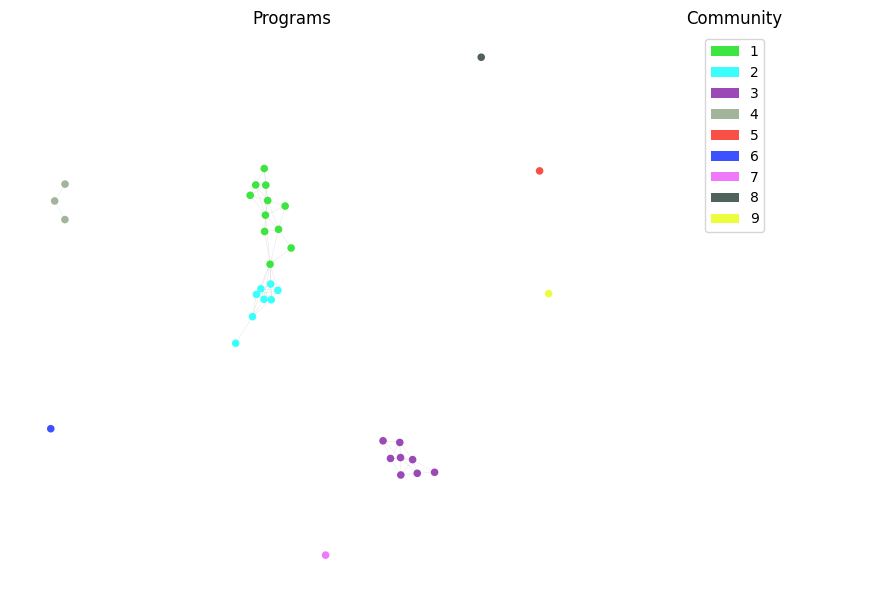

In [13]:
# Assign colors, including one per community, then draw the program network.
colors = mosaicmpi.Colors.from_integration(integration)
colors.add_missing_community_colors(network=network)

fig = mosaicmpi.plot_program_network_communities(network, colors)

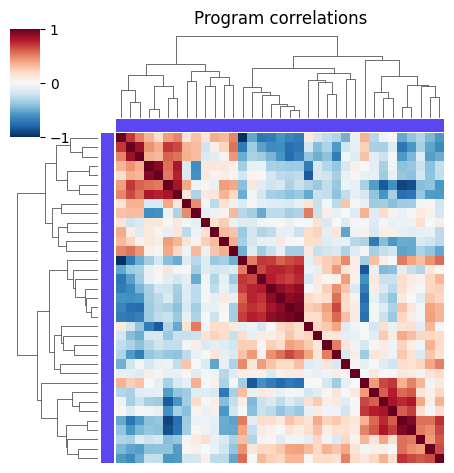

In [14]:
# The program-program correlation matrix underlying the network.
fig = mosaicmpi.plot_program_correlation_matrix(
    integration, colors, figsize=[6, 6], hide_program_labels=True)

Each node is one OT-NMF program (labelled `rank.program`); edges join highly
correlated programs and colors mark the detected communities. A community groups
programs that recur across ranks — the reproducible expression programs mosaicMPI
would carry forward (e.g. to compare or integrate multiple tissues/samples).

## 9. spOT-NMF's own OT-native consensus

Sections 4–8 used **mosaicMPI's built-in consensus**: it clusters the
replicate programs with KMeans + a coordinate-wise **median**, then refits the
usages with **NNLS**. That recipe is designed for plain NMF factors.

spOT-NMF's spectra are gene **probability distributions**, so the package also
ships an **OT-native consensus**, `run_spotnmf_consensus`, that differs in
three ways:

| step | mosaicMPI (cNMF-style) | spOT-NMF consensus |
|---|---|---|
| cluster replicate programs | free KMeans + density filter | **balanced Hungarian `match`** (safe at high *k*) |
| aggregate matched programs | coordinate-wise **median** | **distribution barycenter** (`mean`, or `geomean` = KL barycenter) |
| refit usages | NNLS (least squares) | **entropic-OT** dual solve (keeps the OT usage geometry) |

`stability` is reported as the **cross-replicate agreement** (mean
Hungarian-matched cosine over replicate pairs) — a truer reproducibility
measure than a KMeans silhouette. We run it on the same normalized
highly-variable matrix mosaicMPI just factorized.

In [15]:
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from spotnmf.models import run_spotnmf_consensus

# Reuse the exact normalized HVG matrix mosaicMPI factorized above.
norm = ad.read_h5ad(run.paths["normalized_counts"])
Xn = norm.X.toarray() if hasattr(norm.X, "toarray") else np.asarray(norm.X)
sub = ad.AnnData(X=np.asarray(Xn, dtype=np.float64),
                 obs=pd.DataFrame(index=norm.obs_names),
                 var=pd.DataFrame(index=norm.var_names))
sub.var["highly_variable"] = True

k = 6
with open(os.devnull, "w") as _null, contextlib.redirect_stdout(_null), contextlib.redirect_stderr(_null):
    res, losses, agreement = run_spotnmf_consensus(
        sub, components=k, n_iter=n_iter, seed=0, return_stability=True,
        consensus_method="match", aggregate="mean",   # OT-native defaults
        max_iter=8, max_iter_inner=40, device="cpu",  # small caps for the demo
    )

consensus_usage = res["topics_per_spot"]     # spots x k
consensus_prog  = res["genes_per_topic"]     # genes x k, each program sums to 1
print(f"consensus usages:   {consensus_usage.shape}  (spots x programs)")
print(f"consensus programs: {consensus_prog.shape}  (genes x programs)")
print(f"cross-replicate agreement (stability): {agreement:.3f}")
print("program column sums (gene distributions):",
      np.round(consensus_prog.to_numpy().sum(axis=0), 3))

consensus usages:   (150, 6)  (spots x programs)
consensus programs: (200, 6)  (genes x programs)
cross-replicate agreement (stability): 0.400
program column sums (gene distributions): [1. 1. 1. 1. 1. 1.]


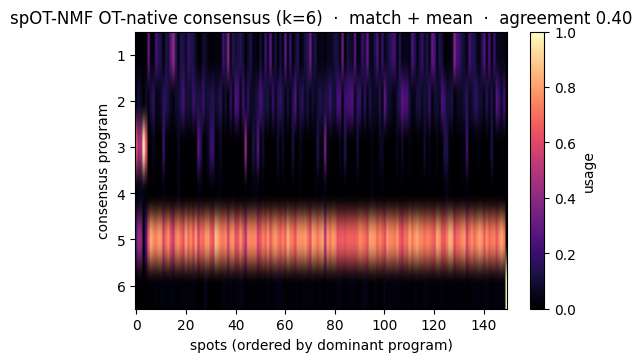

,gene1,gene2,gene3,gene4,gene5
program1,HMGN1,YBX1,RAN,RPS3A,HNRNPU
program2,IFITM3,TRAC,CCL19,YBX1,CR2
program3,IGHGP,IGHG4,IGHG3,RPS3A,MARCKSL1
program4,CXCL13,OST4,IGLC2,IGHG3,LYZ
program5,CALR,SNHG5,MT-CYB,MT-CO1,FTH1
program6,OST4,HINT1,CST3,SRRM2,IL7R


In [16]:
# Consensus usage map: spots ordered by their dominant program.
U = consensus_usage.to_numpy()
order = np.argsort(U.argmax(axis=1))
fig, ax = plt.subplots(figsize=(6, 3.6))
im = ax.imshow(U[order].T, aspect="auto", cmap="magma")
ax.set_xlabel("spots (ordered by dominant program)")
ax.set_ylabel("consensus program")
ax.set_yticks(range(k)); ax.set_yticklabels(range(1, k + 1))
ax.set_title(f"spOT-NMF OT-native consensus (k={k})  \u00b7  "
             f"match + mean  \u00b7  agreement {agreement:.2f}")
fig.colorbar(im, ax=ax, label="usage")
plt.show()

# Top genes per consensus program.
top = {f"program{c+1}": consensus_prog.iloc[:, c].sort_values(ascending=False).head(5).index.tolist()
       for c in range(k)}
pd.DataFrame(top).T.rename(columns=lambda j: f"gene{j+1}")

## Summary

- We ran the **mosaicMPI** consensus / rank-selection pipeline with **spOT-NMF**
  as the factorization engine, changing only `algorithm="spotnmf"`.
- The `spotnmf` backend is contributed by `spotnmf.mosaic` and registered through
  `mosaicmpi.factorization`; the built-in default remains `algorithm="cnmf"`.
- Beyond mosaicMPI's built-in consensus, spOT-NMF also provides its own
  **OT-native consensus** (`run_spotnmf_consensus`): balanced `match`
  clustering + a distribution barycenter (`mean`/`geomean`) + an entropic-OT
  usage refit, with a cross-replicate **agreement** stability score.
- All downstream mosaicMPI features — stability/error curves, usage heatmaps,
  and the **program-correlation network with community detection** (and
  multi-dataset `Integration`) — work identically, because the on-disk result
  format is unchanged.

**To go back to standard cNMF**, drop the `algorithm`/`factorizer_params`
arguments (or set `algorithm="cnmf"`). **To scale up**, use the full dataset, a
wider `kvals` range, and `n_iter=100–200`; consider a GPU via
`factorizer_params={"device": "cuda"}`.